# Feature Engineering
This section is not necessary and was used to map out the features and plot the data. All the functions defined in this section are defined again in the next section.
<!-- Simplify the data into fundamental features -->

In [7]:
# imports and settings

# !pip install crepe
import matplotlib.pyplot as plt
import crepe
import time as t
from scipy.io import wavfile
import numpy as np

# Set the default style to light mode
plt.style.use('default')

### Feature 1: Core Frequency

In [8]:
def get_core_frequency(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return frequency, time

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step


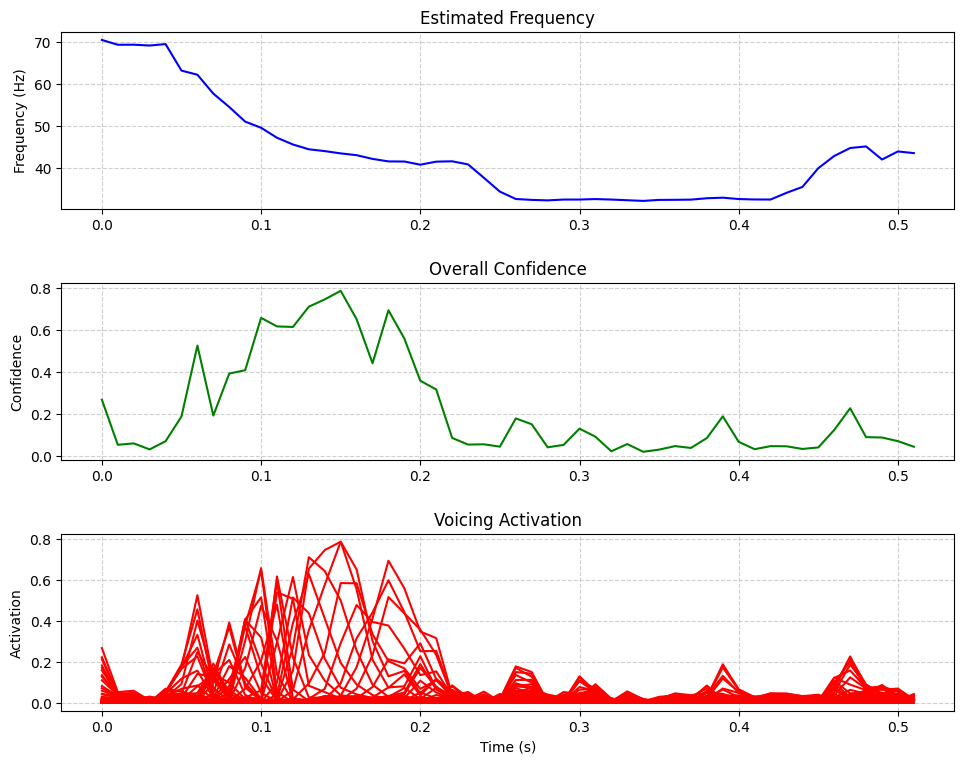

The core frequency is 43.06632351827611 Hz


In [9]:
# Example
sr, audio = wavfile.read("SortedSamples/kicks/ah_kick_gust.wav")
time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)

plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(time, frequency, color='b', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Frequency (Hz)')
plt.title('Estimated Frequency')
plt.tight_layout(pad=2.0)

plt.subplot(3, 1, 2)
plt.plot(time, confidence, color='g', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Confidence')
plt.title('Overall Confidence')
plt.tight_layout(pad=2.0)

plt.subplot(3, 1, 3)
plt.plot(time, activation, color='r', linewidth=1.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylabel('Activation')
plt.xlabel('Time (s)')
plt.title('Voicing Activation')
plt.tight_layout(pad=2.0)
# plt.gca().set_prop_cycle(color=plt.cm.Reds(np.linspace(0.3, 1, len(time))))

plt.show()

print(f'The core frequency is {frequency.mean()} Hz')

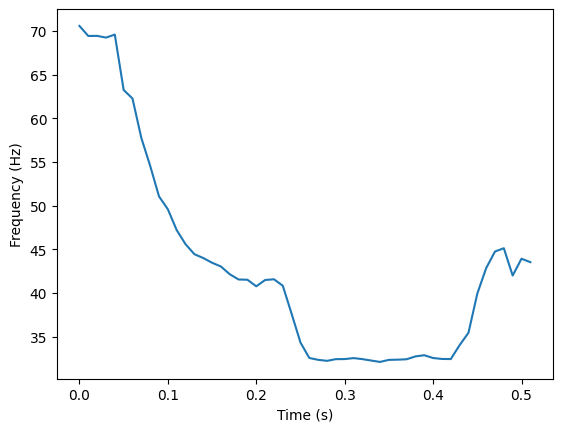

In [10]:
# Plot
plt.plot(time, frequency)
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()

### Feature 2: Max Amplitude

In [11]:
def get_max_amplitude(file_path):
    sr, audio = wavfile.read(file_path)
    return np.max(audio), audio

The max amplitude is 1793682176


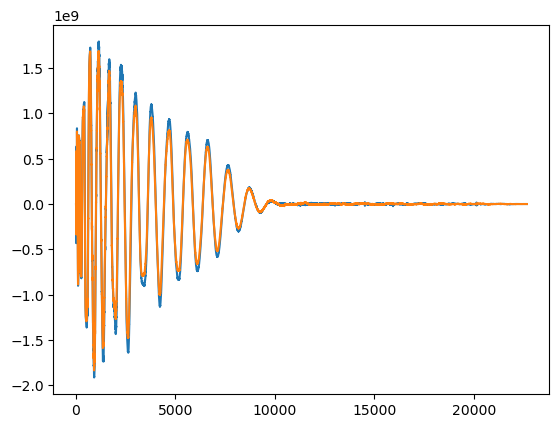

In [54]:
# Example
max_amplitude, audio = get_max_amplitude('SortedSamples/kicks/ah_kick_gust.wav')

print(f'The max amplitude is {max_amplitude}')

# plot the amplitude
plt.plot(audio)

# show the max amplitude on the plot
# plt.text(0, max_amplitude, f'Max amplitude: {max_amplitude}')
plt.show()

### Feature 3: Average Activation

In [12]:
def get_activation(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return time, activation

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step


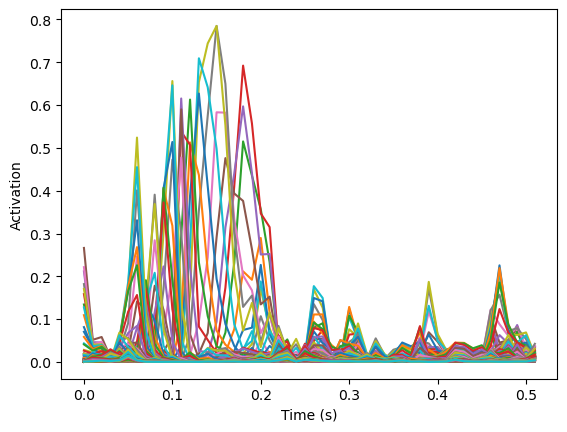

The average activation is 0.006699346471577883


In [56]:
# Example
get_activation('SortedSamples/kicks/ah_kick_gust.wav')

# plot activation
plt.plot(time, activation)
plt.xlabel('Time (s)')
plt.ylabel('Activation')
plt.show()

# avergae the activation
print(f'The average activation is {activation.mean()}')

### Feature 4: Duration

In [13]:
def get_sample_duration(file_path):
    sr, audio = wavfile.read(file_path)
    return len(audio) / sr

In [14]:
# Example
get_sample_duration('SortedSamples/kicks/ah_kick_gust.wav')

print(f'The duration of the sample is {get_sample_duration("SortedSamples/kicks/ah_kick_gust.wav")} seconds')

The duration of the sample is 0.513968253968254 seconds


In [15]:
# Create a dataframe with each of these features given a sample
def get_sample_features(file_path):
    time, activation = get_activation(file_path)
    return {
        'core_frequency': get_core_frequency(file_path),
        'max_amplitude': get_max_amplitude(file_path)[0], 
        'average_activation': activation.mean(),
        'duration': get_sample_duration(file_path)
    }

# # Example
get_sample_features('SortedSamples/kicks/ah_kick_gust.wav')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


{'core_frequency': (array([70.58817888, 69.43397622, 69.45028067, 69.25133494, 69.59423268,
         63.25341196, 62.27124551, 57.75586683, 54.55820634, 51.06148095,
         49.58965156, 47.20184097, 45.59061831, 44.44494047, 44.00854644,
         43.46473634, 43.0354901 , 42.14802774, 41.547632  , 41.51859705,
         40.76544734, 41.48832442, 41.57410696, 40.82990499, 37.61161036,
         34.32251986, 32.55870899, 32.34729265, 32.22989896, 32.42452189,
         32.43226542, 32.54418247, 32.42950664, 32.26294483, 32.10694012,
         32.34299838, 32.36549237, 32.41184486, 32.73812932, 32.87326201,
         32.55281564, 32.44784336, 32.43440795, 34.03106681, 35.44410749,
         39.92921833, 42.84515672, 44.75204408, 45.1275378 , 41.99786369,
         43.92794816, 43.53061411]),
  array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
         0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
         0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29

# Process Data into CSV
The following cell converts various features from each audio sample in a directory labeled "Sorted Samples". It saves the data into a csv called sample_features.csv, which contains the features used for model training and inference.

In [113]:
import os
import pandas as pd
import warnings
from scipy.io import wavfile
import crepe
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

def get_core_frequency(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return frequency.mean()

def get_max_amplitude(file_path):
    sr, audio = wavfile.read(file_path)
    return np.max(audio)

def get_activation(file_path):
    sr, audio = wavfile.read(file_path)
    time, frequency, confidence, activation = crepe.predict(audio, sr, viterbi=True)
    return activation

def get_sample_duration(file_path):
    sr, audio = wavfile.read(file_path)
    return len(audio) / sr

def get_sample_features(file_path):
    return {
        'core_frequency': get_core_frequency(file_path),
        'max_amplitude': get_max_amplitude(file_path),
        'average_activation': get_activation(file_path).mean(),
        'duration': get_sample_duration(file_path)
    }
def process_samples_to_csv():
    samples = []
    types = ['claps', 'cymbals', 'hihats', 'kicks', 'percs', 'rides', 'snares', 'toms']
    for category in types:
        for root, dirs, files in os.walk(f'SortedSamples/{category}'):
            for file in tqdm(files, desc=f"Processing {os.path.basename(root)}", unit="file"):
                if file.endswith('.wav'):
                    try:
                        features = get_sample_features(os.path.join(root, file))
                        features['label'] = os.path.basename(root)
                        samples.append(features)

                        # Convert to DataFrame and save after each file
                        df = pd.DataFrame(samples)
                        df.to_csv(f'sample_features - {category}.csv', index=False)
                    except Exception as e:
                        print(f"Error processing {file}: {e}")
    return samples

samples = process_samples_to_csv()

df = pd.DataFrame(samples)
df.head()

Combines generated dataframes into one main csv

In [29]:
# concatenate all the dataframes into one and save it
# they are saved as ""sample_features - claps.csv", "sample_features - hats.csv", etc.
import os
import pandas as pd

dfs = []
df_claps = pd.read_csv('Sample Features/sample_features - claps.csv')
df_cymbals = pd.read_csv('Sample Features/sample_features - cymbals.csv')
df_hats = pd.read_csv('Sample Features/sample_features - hats.csv')
df_kicks = pd.read_csv('Sample Features/sample_features - kicks.csv')
df_percs = pd.read_csv('Sample Features/sample_features - percs.csv')
df_rides = pd.read_csv('Sample Features/sample_features - rides.csv')
df_snares = pd.read_csv('Sample Features/sample_features - snares.csv')
df_toms = pd.read_csv('Sample Features/sample_features - toms.csv')

dfs = [df_claps, df_cymbals, df_hats, df_kicks, df_percs, df_rides, df_snares, df_toms]
df = pd.concat(dfs)
df.to_csv('sample_features.csv', index=False)

### Analyze the generated data

In [108]:
# load the data and remove the outliers to test accuracy

data = pd.read_csv('sample_features.csv')
# Remove duration outliers
# data = data[data['duration'] < 15]
data = data[data['label'] != 'perc']
# data = data[data['label'] != 'ride']
# data = data[data['label'] != 'cymbal']
# data = data[data['label'] != 'clap']
# data = data[data['label'] != 'tom']

# merge the rides and cymbals into rides
data['label'] = data['label'].replace('cymbal', 'ride')

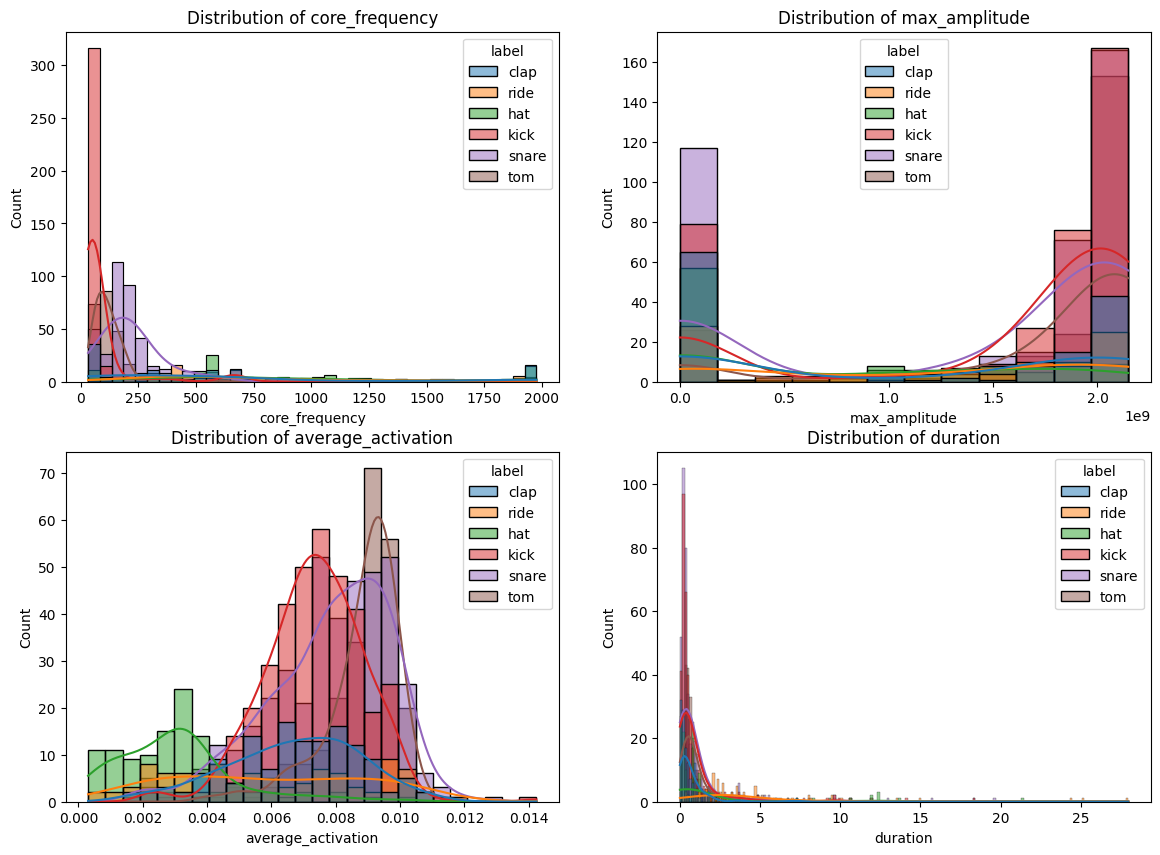

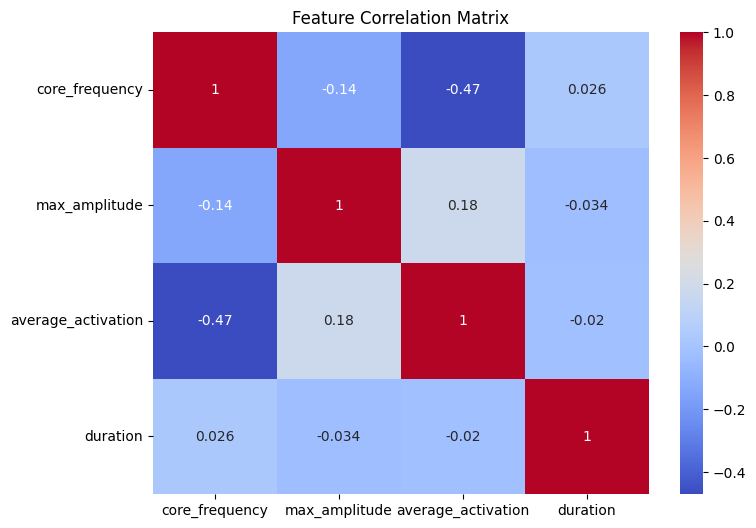

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plot feature distributions to understand their characteristics
plt.figure(figsize=(14, 10))
for i, column in enumerate(data.columns[:-1], 1):  # Exclude label column
    plt.subplot(2, 2, i)
    sns.histplot(data, x=column, hue='label', kde=True)
    plt.title(f'Distribution of {column}')

# Display correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [110]:
data["label"].value_counts()
# data = data.drop(columns=['duration'])
# data[data['duration'] > 15].count()

label
snare    401
kick     367
tom      241
clap     138
hat      111
ride      96
Name: count, dtype: int64

# Analyze various models

In [107]:
from sklearn.metrics import classification_report

# Prepare features and labels
X = data.drop('label', axis=1)
y = data['label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Gradient Boosting': GradientBoostingClassifier(),
    'k-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression()
}

# Train and evaluate each model
model_reports = {}
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    report = classification_report(y_test, y_pred, output_dict=True)
    model_reports[model_name] = report

# Display the classification report for each model
for model_name, report in model_reports.items():
    print(f"Classification Report for {model_name}:")
    report_df = pd.DataFrame(report).transpose()
    display(report_df[['precision']])
    print("\n")


Classification Report for Gradient Boosting:


,precision
clap,0.562500
hat,0.888889
kick,0.825000
ride,0.500000
snare,0.686047
tom,0.659091
accuracy,0.723247
macro avg,0.686921
weighted avg,0.724420




Classification Report for k-Nearest Neighbors:


,precision
clap,0.391304
hat,0.800000
kick,0.731707
ride,0.545455
snare,0.697368
tom,0.571429
accuracy,0.664207
macro avg,0.622877
weighted avg,0.661541




Classification Report for Support Vector Machine:


,precision
clap,0.538462
hat,0.862069
kick,0.716049
ride,0.466667
snare,0.675000
tom,0.547170
accuracy,0.664207
macro avg,0.634236
weighted avg,0.663276




Classification Report for Random Forest:


,precision
clap,0.500000
hat,0.888889
kick,0.821429
ride,0.500000
snare,0.728395
tom,0.720930
accuracy,0.741697
macro avg,0.693274
weighted avg,0.740113




Classification Report for Logistic Regression:


,precision
clap,0.400000
hat,0.750000
kick,0.681818
ride,0.375000
snare,0.593023
tom,0.472727
accuracy,0.597786
macro avg,0.545428
weighted avg,0.588187


## Notes:
* removing percs improves the overall ccuracy by about 5-6%
* with a lowerer of labels (kicks, snares, hats), as well as filtering time < 5, the accuracy for gradient boosting and random forest sits around 87%
* Removing rides percs improves the accruacy
    * consider adding more rides and percs to the dataset
    * removing the time column makes the average accuracy across all models to around 70% (if rides and percs are removed)